In [140]:
# Deep Learning Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os


# Keras Libraries

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import VGG16

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# Evaluation Libraries
!pip install seaborn
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [141]:
print("TensorFlow Version:")
print(tf.__version__)


print("\nGPU Available:")

print(
    tf.config.list_physical_devices('GPU')
)

TensorFlow Version:
2.21.0

GPU Available:
[]


In [142]:
classes = os.listdir('/Users/aathilhakam/Desktop/DL/Project/Plant-Disease-Detection/PlantVillage')

print(classes)

['Tomato_healthy', 'Potato___Early_blight', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Early_blight', '.DS_Store', 'Tomato__Target_Spot', 'Potato___Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Septoria_leaf_spot', 'Tomato__Tomato_mosaic_virus', 'Pepper__bell___Bacterial_spot', 'Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Pepper__bell___healthy', 'Potato___healthy']


In [143]:
len(classes)


16

In [144]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [145]:
validation_split=0.2

In [146]:
dataset_path = "/Users/aathilhakam/Desktop/DL/Project/Plant-Disease-Detection/PlantVillage"

In [147]:
IMAGE_SIZE = 224

BATCH_SIZE = 32

In [148]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=30,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)

In [149]:
import os

print(dataset_path)

/Users/aathilhakam/Desktop/DL/Project/Plant-Disease-Detection/PlantVillage


In [150]:
train_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="training"

)

Found 3345 images belonging to 15 classes.


In [151]:
validation_data = train_datagen.flow_from_directory(

    dataset_path,

    target_size=(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="validation"

)

Found 827 images belonging to 15 classes.


In [152]:
class_names = train_data.class_indices

class_names

{'Pepper__bell___Bacterial_spot': 0,
 'Pepper__bell___healthy': 1,
 'Potato___Early_blight': 2,
 'Potato___Late_blight': 3,
 'Potato___healthy': 4,
 'Tomato_Bacterial_spot': 5,
 'Tomato_Early_blight': 6,
 'Tomato_Late_blight': 7,
 'Tomato_Leaf_Mold': 8,
 'Tomato_Septoria_leaf_spot': 9,
 'Tomato_Spider_mites_Two_spotted_spider_mite': 10,
 'Tomato__Target_Spot': 11,
 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12,
 'Tomato__Tomato_mosaic_virus': 13,
 'Tomato_healthy': 14}

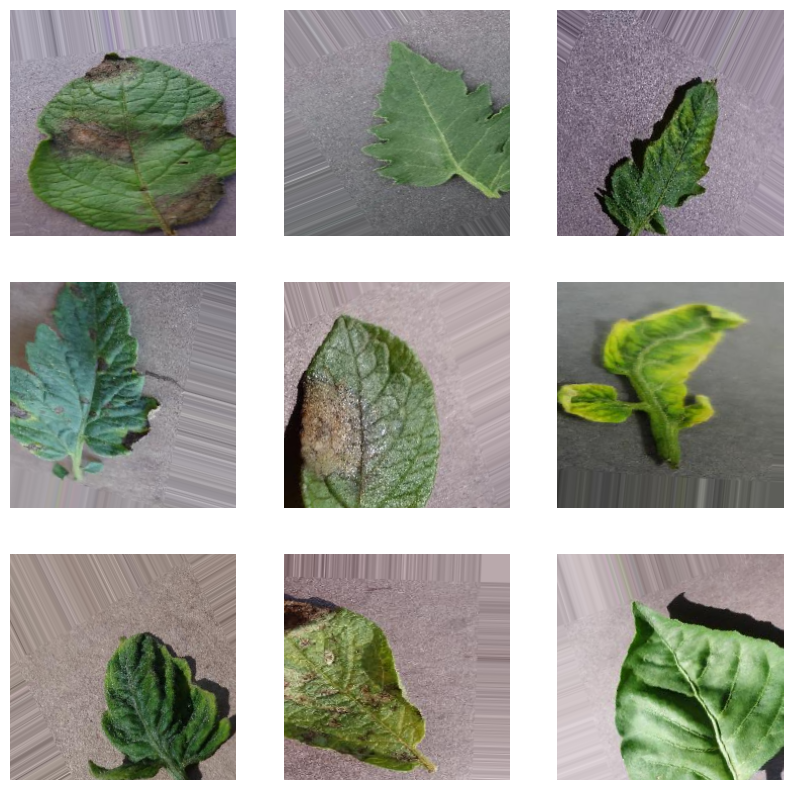

In [153]:
images, labels = next(train_data)


plt.figure(figsize=(10,10))


for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")


plt.show()

In [154]:
base_model = VGG16(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

In [155]:
# Freeze early layers
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Fine-tune last 10 layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

In [156]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 13,569,280 (51.76 MB)

 Non-trainable params: 1,145,408 (4.37 MB)

In [157]:
x = base_model.output


x = GlobalAveragePooling2D()(x)


x = Dense(
    512,
    activation="relu"
)(x)


x = BatchNormalization()(x)


x = Dropout(
    0.5
)(x)



x = Dense(
    256,
    activation="relu"
)(x)


x = Dropout(
    0.3
)(x)



output = Dense(
    train_data.num_classes,
    activation="softmax"
)(x)

In [158]:
model = Model(

    inputs=base_model.input,

    outputs=output

)

In [159]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,32

 Total params: 15,114,575 (57.66 MB)

 Trainable params: 13,968,143 (53.28 MB)

 Non-trainable params: 1,146,432 (4.37 MB)

In [160]:
model.compile(

    optimizer=Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [161]:
early_stop = EarlyStopping(

    monitor="val_accuracy",

    patience=5,

    restore_best_weights=True

)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3

)


checkpoint = ModelCheckpoint(

    "best_vgg16_model.keras",

    monitor="val_accuracy",

    save_best_only=True

)

In [162]:
history = model.fit(

    train_data,

    validation_data=validation_data,

    epochs=40,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ]

)

Epoch 1/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 614s 6s/step - accuracy: 0.1647 - loss: 2.7299 - val_accuracy: 0.2322 - val_loss: 2.6002 - learning_rate: 1.0000e-05
Epoch 2/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 727s 7s/step - accuracy: 0.3677 - loss: 1.9762 - val_accuracy: 0.4752 - val_loss: 2.2751 - learning_rate: 1.0000e-05
Epoch 3/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 654s 6s/step - accuracy: 0.5001 - loss: 1.5649 - val_accuracy: 0.6723 - val_loss: 1.7864 - learning_rate: 1.0000e-05
Epoch 4/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 637s 6s/step - accuracy: 0.6045 - loss: 1.2819 - val_accuracy: 0.7557 - val_loss: 1.3137 - learning_rate: 1.0000e-05
Epoch 5/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 622s 6s/step - accuracy: 0.6753 - loss: 1.0823 - val_accuracy: 0.8114 - val_loss: 0.8330 - learning_rate: 1.0000e-05
Epoch 6/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 613s 6s/step - accuracy: 0.7148 - loss: 0.9563 - val_accuracy: 0.8440 - val_loss: 0.6763 - learning_rate: 1.0000e-05
Epoch 7/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 654s 6s/step - acc

KeyboardInterrupt: 

In [163]:
import os

print(os.path.getsize("best_vgg16_model.keras"))

172319634


In [164]:
from tensorflow.keras.models import load_model

model = load_model("best_vgg16_model.keras")

print("Model loaded successfully")

Model loaded successfully


In [165]:
loss, accuracy = model.evaluate(
    validation_data
)

print("Validation Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9311 - loss: 0.2437
Validation Accuracy: 0.931076169013977


In [166]:
for layer in model.layers[-10:]:
    layer.trainable = True

In [167]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [168]:
history_fine = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop
    ]
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 610s 6s/step - accuracy: 0.9208 - loss: 0.2869 - val_accuracy: 0.9166 - val_loss: 0.3060 - learning_rate: 1.0000e-05
Epoch 2/10
  1/105 ━━━━━━━━━━━━━━━━━━━━ 9:42 6s/step - accuracy: 0.9062 - loss: 0.4798

KeyboardInterrupt: 

In [169]:
class StopAtAccuracy(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        accuracy = logs.get("accuracy")
        
        if accuracy >= 0.92:
            print("\nReached target accuracy. Stopping training.")
            self.model.stop_training = True

In [170]:
stop_callback = StopAtAccuracy()

history_fine = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop,
        stop_callback
    ]
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9232 - loss: 0.2731
Reached target accuracy. Stopping training.
105/105 ━━━━━━━━━━━━━━━━━━━━ 555s 5s/step - accuracy: 0.9232 - loss: 0.2731 - val_accuracy: 0.9226 - val_loss: 0.2652 - learning_rate: 1.0000e-05


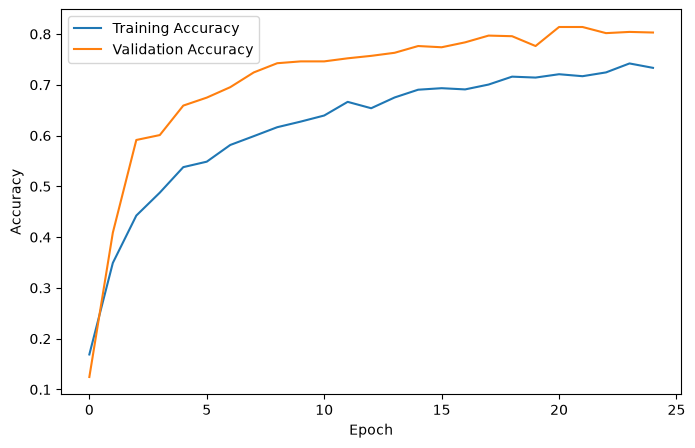

In [171]:
plt.figure(figsize=(8,5))


plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)


plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

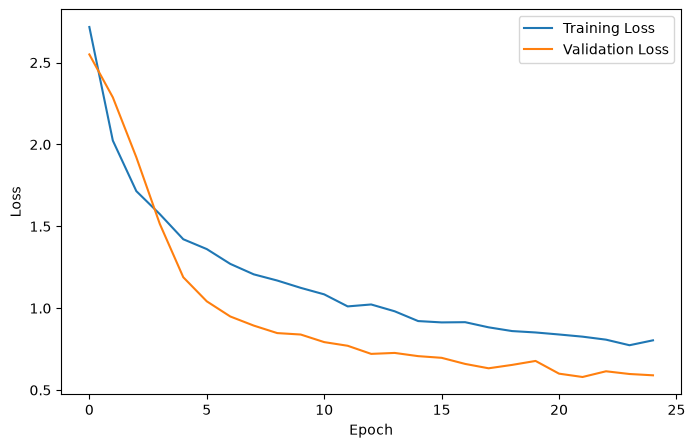

In [172]:
plt.figure(figsize=(8,5))


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [173]:
# Reset validation generator
validation_data.reset()

# Predict classes
predictions = model.predict(validation_data)

# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)

# Get actual labels
true_classes = validation_data.classes

# Get class names
class_labels = list(validation_data.class_indices.keys())

26/26 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step


In [174]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

cm

array([[ 4,  1,  1,  4,  2,  4,  6,  2,  8,  2,  1,  2,  6,  4,  5],
       [ 0,  0,  1,  0,  1,  0,  1,  0,  0,  1,  0,  3,  3,  0,  0],
       [ 2,  2,  4,  6,  1,  2,  5,  2,  4,  6,  0,  6,  1,  6,  9],
       [ 4,  1,  5,  6,  1,  2,  2,  7,  7,  3,  5,  3,  8,  7,  5],
       [ 2,  0,  0,  3,  2,  2,  3,  0,  2,  1,  4,  3,  2,  1,  5],
       [ 6,  0,  6,  6,  4,  1,  5,  7,  4,  0,  1,  3,  9,  4,  2],
       [ 1,  0,  8,  5,  1,  4,  9,  6,  4,  3,  3,  4, 14,  6,  4],
       [ 3,  1,  3, 10,  3,  9,  3,  5,  5,  7,  3,  4,  0,  4,  7],
       [ 7,  0,  4,  5,  3,  5,  3,  2,  3,  3,  3,  5,  4,  2,  4],
       [ 5,  2,  7, 11,  3,  4,  6,  3,  3,  3,  4,  2,  5,  4,  6],
       [ 2,  1,  2,  2,  2,  2,  2,  7,  5,  5,  2,  3,  2,  3,  3],
       [ 3,  0,  0,  4,  1,  7,  4,  4,  2,  4,  3,  2,  9,  4,  2],
       [ 5,  0,  4,  7,  1, 11,  5,  7,  6,  9,  3,  6,  7,  4,  5],
       [ 1,  2,  5,  9,  0,  5,  7,  2,  6,  4,  2,  5,  7,  4,  3],
       [ 4,  1,  2,  6,  2,  5,  2

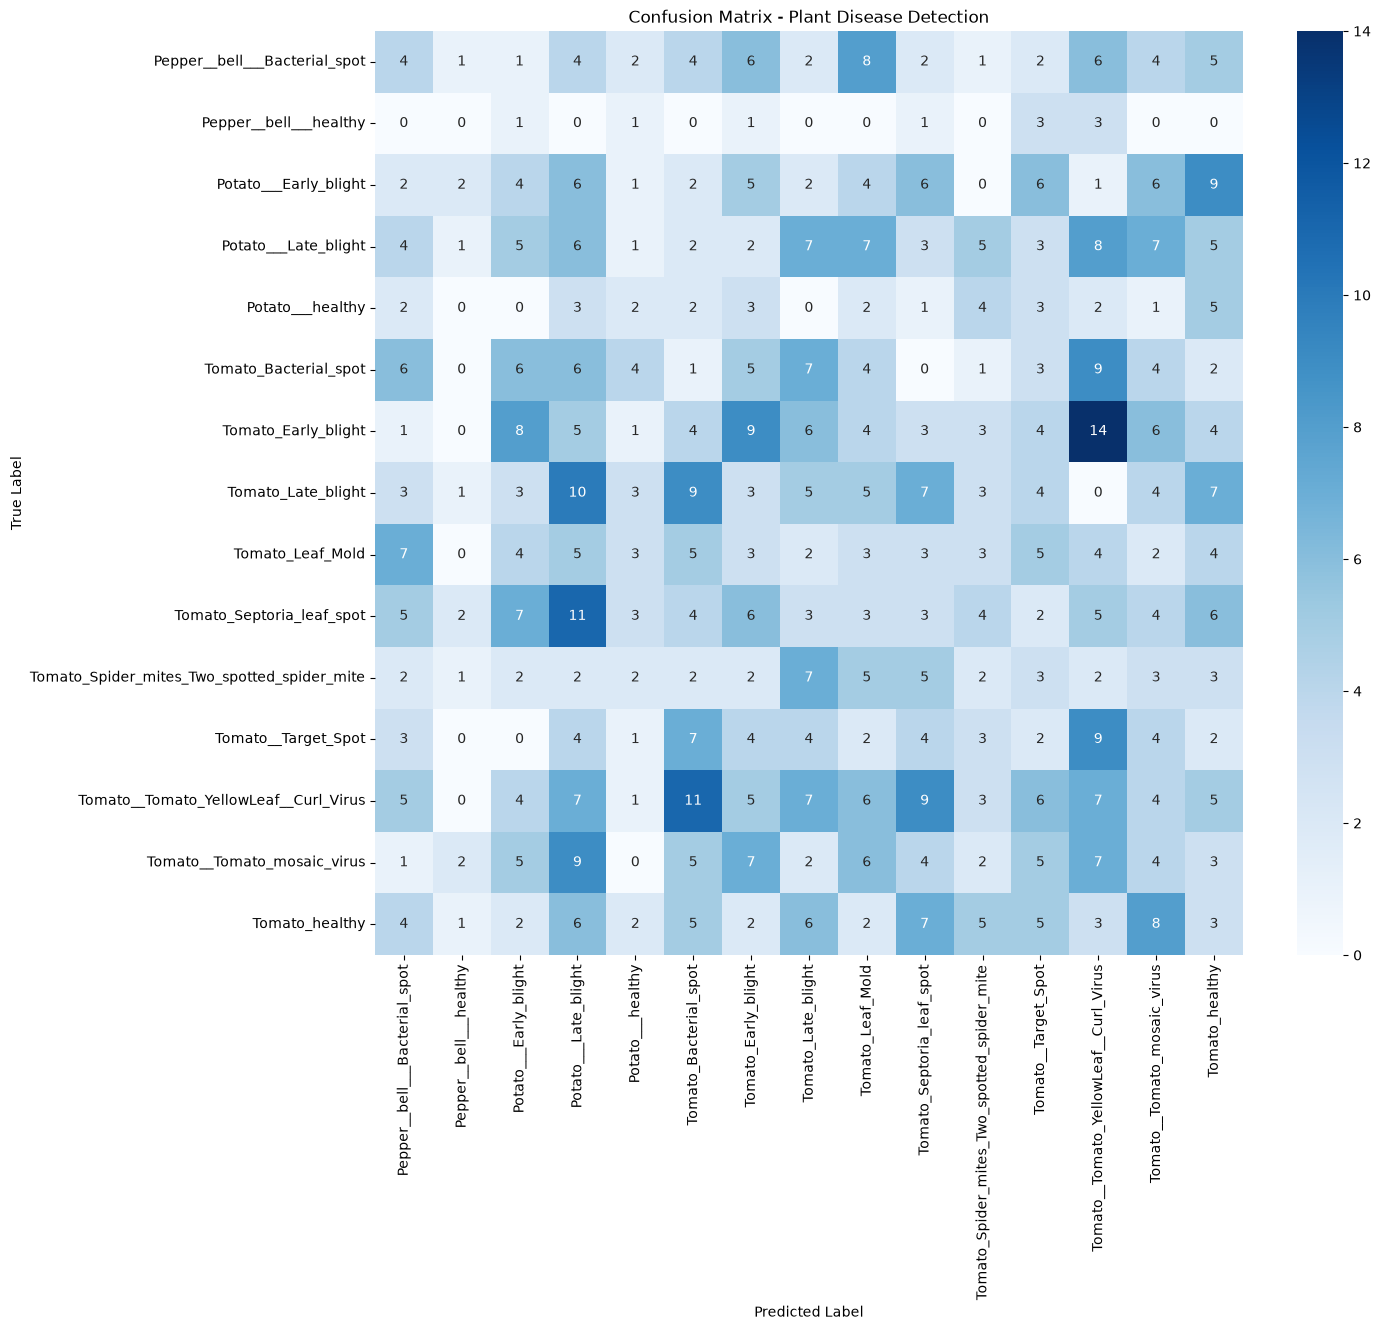

In [175]:
plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix - Plant Disease Detection")

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.show()